### In this exercise we are going to explain and calculate what a KPI is.

#### A KPI (Key Performance Indicator) is a measurable value that demonstrates how effectively a company is achieving its key business objectives.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Order_ID': ['ORD-01', 'ORD-02', 'ORD-03', 'ORD-04', 'ORD-05', 'ORD-06', 'ORD-07', 'ORD-08'],
    'Item': ['Notebook Lenovo', 'Auriculares', 'Paleta Head', 'Botines Nike', 'Monitor', 'Teclado Redragon', 'Mouse', 'Mousepad'],
    'Status': ['Delivered', 'Delivered', 'Delayed', 'Delivered', 'Cancelled', 'Delivered', 'Delayed', 'Delivered'],
    'Delivery_Days': [2, 3, 5, 1, pd.NA, 2, 6, 2]
}
df_kpi = pd.DataFrame(data)

print("Registro Histórico de Envíos:")
display(df_kpi)

Registro Histórico de Envíos:


,Order_ID,Item,Status,Delivery_Days
0,ORD-01,Notebook Lenovo,Delivered,2
1,ORD-02,Auriculares,Delivered,3
2,ORD-03,Paleta Head,Delayed,5
3,ORD-04,Botines Nike,Delivered,1
4,ORD-05,Monitor,Cancelled,<NA>
5,ORD-06,Teclado Redragon,Delivered,2
6,ORD-07,Mouse,Delayed,6
7,ORD-08,Mousepad,Delivered,2


#### Today, we are going to create two of the most critical KPIs for the logistics industry.

#### For the first KPI, we are going to calculate the Average Delivery Time. We will assign this value to a variable named Avg_Delivery_Time.

The Average Delivery Time is: 3.0 days


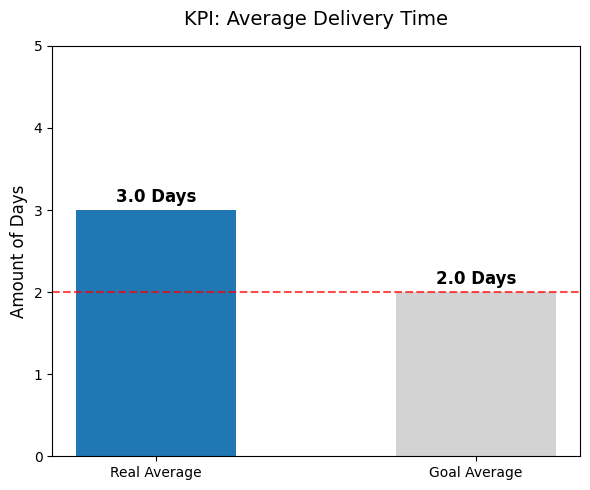

In [14]:
Avg_Delivery_Time = df_kpi['Delivery_Days'].mean()
Target_Time = 2.0

print(f"The Average Delivery Time is: {Avg_Delivery_Time:.1f} days")

plt.figure(figsize=(6, 5))

category = ['Real Average', 'Goal Average']
values= [Avg_Delivery_Time, Target_Time]
colors= ['#1f77b4', '#d3d3d3']

bars = plt.bar(category, values, color=colors, width=0.5)

plt.bar_label(bars, fmt='%.1f Days', padding=3, fontsize=12, fontweight='bold')
plt.axhline(y=Target_Time, color='red', linestyle='--', alpha=0.7)

plt.title("KPI: Average Delivery Time", fontsize=14, pad=15)
plt.ylabel("Amount of Days", fontsize=12)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

#### For the second KPI, we are going to calculate the On-Time Delivery Rate. We cannot calculate this metric if a delivery was cancelled, so first, we must clean the DataFrame by filtering out all cancelled deliveries.

In [11]:
df_valid_orders= df_kpi[df_kpi['Status'] != 'Cancelled'].copy()

df_valid_orders['On_Time_Flag'] = df_valid_orders['Delivery_Days'] <= 2.0

total_valid= len(df_valid_orders)
on_time_count = df_valid_orders['On_Time_Flag'].sum()

otd_rate = (on_time_count/total_valid) * 100

print("Dataframe with the on_time_flag")
display(df_valid_orders)

print(f"\nKPI: The On-Time Delivery Rate is {otd_rate:.1f}%")

Dataframe with the on_time_flag


,Order_ID,Item,Status,Delivery_Days,On_Time_Flag
0,ORD-01,Notebook Lenovo,Delivered,2,True
1,ORD-02,Auriculares,Delivered,3,False
2,ORD-03,Paleta Head,Delayed,5,False
3,ORD-04,Botines Nike,Delivered,1,True
5,ORD-06,Teclado Redragon,Delivered,2,True
6,ORD-07,Mouse,Delayed,6,False
7,ORD-08,Mousepad,Delivered,2,True



KPI: The On-Time Delivery Rate is 57.1%
